# Collecting Data - Preprocessing and Data Acquisition Test
This notebook tests the classes for data acquisition, technical indicator calculation, and preprocessing.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Add project root to path
sys.path.append(str(Path.cwd().parent))

from Collecting_Data.utils import TechnicalIndicators
from Collecting_Data.mt5data import MT5DataLoader
from Collecting_Data.Price import YFinanceDataLoader
from Collecting_Data.preproc_single_inout import SingleInOutPreprocessor
from Collecting_Data.preproc_multi_inout import MultiInOutPreprocessor
from Collecting_Data.preproc_pivot import PivotPreprocessor
from Collecting_Data.indicators import IndicatorEngine


## 1. Test Technical Indicators (utils.py)


## 3. Test Indicator Engine (indicators.py)


In [ ]:
# Create a dummy dataset for quick testing if real data is missing
n = 1000
np.random.seed(42)
prices = 1.2500 + np.cumsum(np.random.randn(n) * 0.0002)
df_dummy = pd.DataFrame({
    'Datetime': pd.date_range('2024-01-01', periods=n, freq='5min'),
    'Open': prices + np.random.randn(n) * 0.0001,
    'High': prices + np.abs(np.random.randn(n)) * 0.0003,
    'Low': prices - np.abs(np.random.randn(n)) * 0.0003,
    'Close': prices,
    'TickVolume': np.random.randint(100, 1000, n),
    'Spread': np.zeros(n)
})

engine = IndicatorEngine(dropna=True)
df_enriched = engine.calculate(df_dummy)
print(f"Enriched data shape: {df_enriched.shape}")
display(df_enriched.head(10))


### 3.1 Visualization of New Indicators


In [ ]:
plt.figure(figsize=(15, 12))

# Subplot 1: Price and EMAs
plt.subplot(3, 1, 1)
plt.plot(df_enriched['Close'].tail(300), label='Close', color='black', alpha=0.5)
plt.plot(df_enriched['ema_21'].tail(300), label='EMA 21')
plt.plot(df_enriched['ema_50'].tail(300), label='EMA 50')
plt.plot(df_enriched['ema_600'].tail(300), label='EMA 600')
plt.title('Price and EMAs (Layer 1)')
plt.legend()

# Subplot 2: EMA Distance and Slope
plt.subplot(3, 1, 2)
plt.plot(df_enriched['dist_ema_50'].tail(300), label='Dist EMA 50', color='blue')
plt.plot(df_enriched['ema_slope_600'].tail(300), label='EMA Slope 600', color='red')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title('EMA Relative Features (Layer 2)')
plt.legend()

# Subplot 3: Candle Metadata (Body Ratio)
plt.subplot(3, 1, 3)
plt.bar(df_enriched.tail(100).index, df_enriched['body_ratio'].tail(100), label='Body Ratio', color='gray')
plt.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Avg Body Size Line')
plt.title('Candle Metadata: Body Ratio (Layer 2)')
plt.legend()

plt.tight_layout()
plt.show()


In [2]:
# Load sample data
data_path = Path.cwd().parent / "Data" / "GBPUSD_1h.csv"
if data_path.exists():
    df_raw = pd.read_csv(data_path)
    ti = TechnicalIndicators()
    df_indicators = ti.add_all_indicators(df_raw)
    print(f"Indicators added. New shape: {df_indicators.shape}")
    display(df_indicators[['Close', 'EMA_50', 'RSI', 'MACD', 'ATR']].head())
else:
    print("GBPUSD_1h.csv not found, skipping indicator test.")


Preprocessed shape: (12311, 22)


,Open,High,Low,Close,Vol,EMA_50,EMA_200,RSI,MACD,MACD_Signal,...,Upper_Shadow,Lower_Shadow,Tenkan_Sen,Kijun_Sen,Senkou_Span_A,Senkou_Span_B,Chikou_Span_Rel,Price_Change,Binary_Label,Multi_Label
77,1.341814,1.342606,1.341400,1.342318,0,1.340943,1.346384,52.096522,0.000660,0.000640,...,0.000288,0.000414,1.341546,1.338863,1.338564,1.341079,0.008077,0.000216,1,3
78,1.342408,1.343797,1.341994,1.342534,0,1.341006,1.346346,69.584924,0.000694,0.000651,...,0.001263,0.000414,1.341861,1.339429,1.338564,1.340914,0.006350,0.000631,1,3
79,1.342408,1.343165,1.341850,1.343165,0,1.341090,1.346314,63.902608,0.000764,0.000673,...,0.000000,0.000558,1.341861,1.339429,1.338564,1.340731,0.006142,-0.001586,0,0
80,1.343238,1.343671,1.341562,1.341580,0,1.341110,1.346267,48.164777,0.000683,0.000675,...,0.000433,0.000018,1.341861,1.339429,1.338307,1.340227,0.004306,-0.002623,0,0
81,1.341328,1.341490,1.338903,1.338957,0,1.341025,1.346194,38.405409,0.000403,0.000621,...,0.000162,0.000054,1.341350,1.340169,1.337688,1.339569,0.002612,0.001903,1,4


## 2. Test Data Loaders (mt5data.py & Price.py)


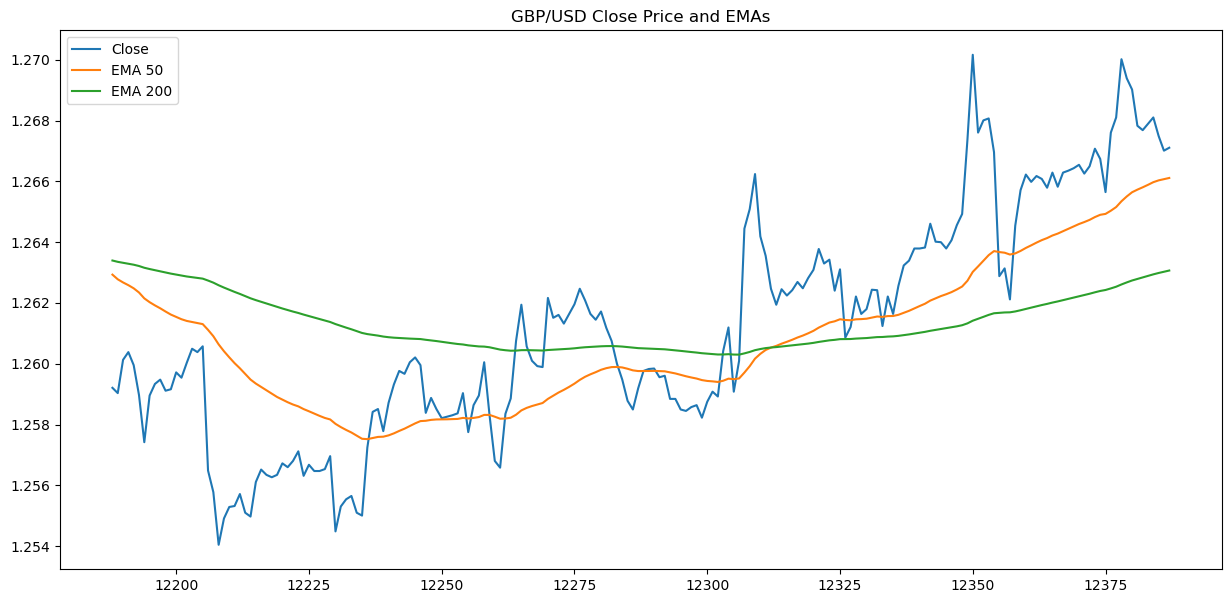

In [3]:
# Test YFinanceDataLoader
yf_loader = YFinanceDataLoader()
yf_df = yf_loader.download_data(period='1mo', interval='1h')
if yf_df is not None:
    print("YFinance data downloaded successfully.")
    display(yf_df.head())

# Test MT5DataLoader (Requires MT5 Terminal and credentials)
print("\nTesting MT5DataLoader (Mocked initialization test)...")
mt5_loader = MT5DataLoader()
print("MT5DataLoader initialized. (Real connection requires MT5 terminal)")


## 3. Test Preprocessors


In [ ]:
# 3.1 SingleInOutPreprocessor
print("Testing SingleInOutPreprocessor...")
preproc_s = SingleInOutPreprocessor()
df_s = preproc_s.preprocess("GBPUSD_1h.csv")
if df_s is not None:
    print(f"Single InOut shape: {df_s.shape}")
    display(df_s.head())

# 3.2 MultiInOutPreprocessor
print("\nTesting MultiInOutPreprocessor...")
preproc_m = MultiInOutPreprocessor()
X, y = preproc_m.preprocess("GBPUSD_1h.csv", num_input_candles=24, num_output_candles=1)
if X is not None:
    print(f"Multi InOut shapes - X: {X.shape}, y: {y.shape}")

# 3.3 PivotPreprocessor
print("\nTesting PivotPreprocessor...")
preproc_p = PivotPreprocessor()
df_p = preproc_p.preprocess("GBPUSD_1h.csv")
if df_p is not None:
    print(f"Pivot data shape: {df_p.shape}")


## 4. Visualizing Features


In [ ]:
if 'df_indicators' in locals():
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 1, 1)
    plt.plot(df_indicators['Close'].tail(200), label='Close')
    plt.plot(df_indicators['EMA_50'].tail(200), label='EMA 50')
    plt.plot(df_indicators['EMA_200'].tail(200), label='EMA 200')
    plt.title("Price and EMAs")
    plt.legend()
    
    plt.subplot(2, 1, 2)
    plt.plot(df_indicators['RSI'].tail(200), label='RSI', color='purple')
    plt.axhline(70, linestyle='--', alpha=0.5, color='red')
    plt.axhline(30, linestyle='--', alpha=0.5, color='green')
    plt.title("RSI")
    plt.legend()
    
    plt.tight_layout()
    plt.show()


Pivot data shape: (12288, 23)


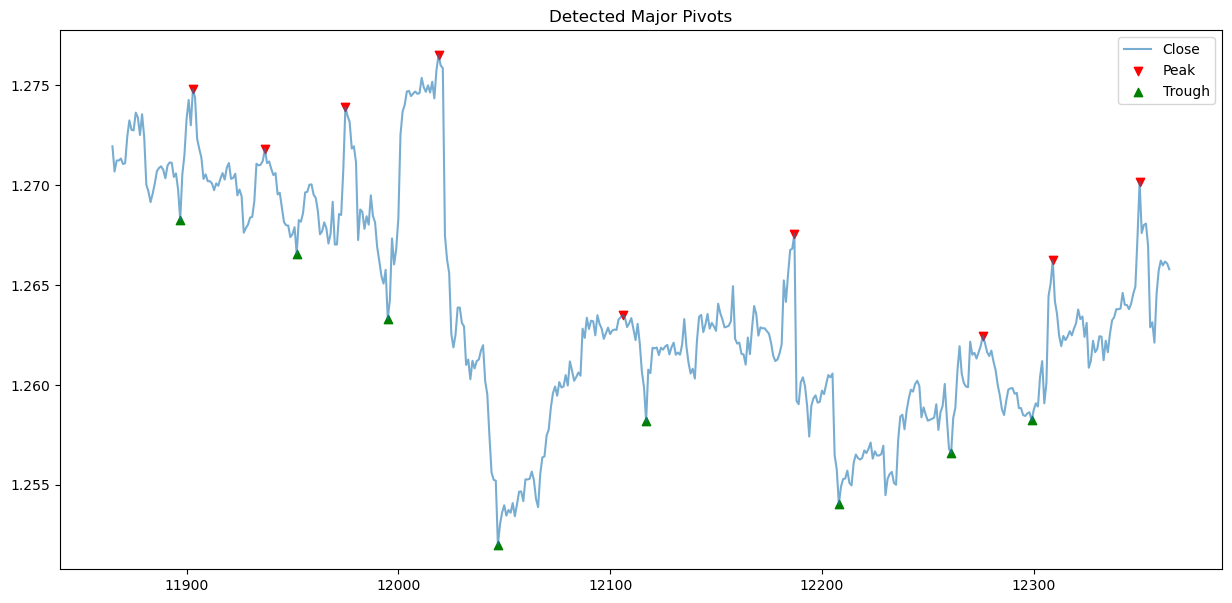

In [4]:
# Test PivotPreprocessor
pivot_preproc = PivotPreprocessor()
df_pivot = pivot_preproc.preprocess("GBPUSD_1h.csv")
if df_pivot is not None:
    print(f"Pivot data shape: {df_pivot.shape}")

    # Plot Pivots
    sample = df_pivot.tail(500)
    plt.figure(figsize=(15, 7))
    plt.plot(sample['Close'], label='Close', alpha=0.6)
    plt.scatter(sample[sample['Peak']==1].index, sample[sample['Peak']==1]['Close'], color='red', label='Peak', marker='v')
    plt.scatter(sample[sample['Trough']==1].index, sample[sample['Trough']==1]['Close'], color='green', label='Trough', marker='^')
    plt.title("Detected Major Pivots")
    plt.legend()
    plt.show()
else:
    print("Error: Pivot preprocessing failed (possibly file not found).")
